# State of the Art Comparison

In this notebook we will benchmark our model against the SOA with the full dataset.

In [2]:
# SETUP
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed, EarlyStoppingCallback
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import random
import os

# Device setup (CUDA GPU / Apple Silicon / CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
else:
    device = torch.device("cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Seeds
def lock_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    set_seed(seed)

lock_seeds(7994)

# Load data
df = pd.read_csv("../data/cleaned_sarcasm_dataset.csv")

X_train = df[df['split']=='train'].copy()
X_test = df[df['split']=='test'].copy()

y_train = X_train[['label']]
y_test = X_test[['label']]

# Tokenizer setup
text_col = 'Sentence'
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples[text_col], padding="max_length", truncation=True)

# Build eval set (same holdout as Part 2)
df_unseen = X_test.copy()
df_unseen['labels'] = df_unseen['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})
df_unseen_clean = df_unseen.drop(columns=['label'])

eval_dataset = Dataset.from_pandas(df_unseen_clean)
if '__index_level_0__' in eval_dataset.column_names:
    eval_dataset = eval_dataset.remove_columns(['__index_level_0__'])

tokenized_eval = eval_dataset.map(tokenize_function, batched=True)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(X_train['label'].head())

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


Map: 100%|██████████| 734/734 [00:00<00:00, 3825.36 examples/s]

X_train shape: (2936, 10), X_test shape: (734, 10)
0        Sarcastic
1    Non-Sarcastic
4        Sarcastic
5        Sarcastic
6        Sarcastic
Name: label, dtype: str


### a) Full Dataset Training

In this section we are going to train our model with varying percentages of the full dataset. (1%, 10%, 25%, 50%, 75% and 100%). The model that we are training is the same one that we trained in Part 2 section a), so the DistilBert model. 

In [3]:

# Percentages of the full training set to use
percentages = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]

results_full = []

for pct in percentages: # - Loop AI mark 
    set_seed(11)

    if pct < 1.00:
        parts = []
        for label_val, group in X_train.groupby('label'):
            n = max(1, int(len(group) * pct))
            parts.append(group.sample(n=n, random_state=749))
        df_pct = pd.concat(parts).reset_index(drop=True)
    else:
        df_pct = X_train.reset_index(drop=True)

    df_pct = df_pct.copy() #For avoiding having problems with same kernel rewriting previous data 
    df_pct['labels'] = df_pct['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})
    df_pct_clean = df_pct.drop(columns=['label'])

    train_ds = Dataset.from_pandas(df_pct_clean)
    if '__index_level_0__' in train_ds.column_names:
        train_ds = train_ds.remove_columns(['__index_level_0__'])

    tokenized_train_pct = train_ds.map(tokenize_function, batched=True)

    # Fresh DistilBERT, frozen backbone
    model_name = "distilbert-base-uncased"
    model_pct = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    for param in model_pct.distilbert.parameters():
        param.requires_grad = False

    training_args_pct = TrainingArguments(
        output_dir=f"../results_pct_{int(pct*100)}",
        num_train_epochs=15,
        learning_rate=5e-4,
        per_device_train_batch_size=8,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        seed=7994,
        logging_steps=1,
        report_to="none",
    )

    trainer_pct = Trainer(
        model=model_pct,
        args=training_args_pct,
        train_dataset=tokenized_train_pct,
        eval_dataset=tokenized_eval,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print(f"\nTraining with {int(pct*100)}% of the training data ({len(df_pct_clean)} samples)...")
    trainer_pct.train()

    predictions_pct = trainer_pct.predict(tokenized_eval)
    preds_pct = np.argmax(predictions_pct.predictions, axis=-1)
    true_pct = predictions_pct.label_ids

    macro_f1 = f1_score(true_pct, preds_pct, average='macro', zero_division=0)
    acc = (preds_pct == true_pct).mean()

    results_full.append({
        'percentage': pct,
        'n_samples': len(df_pct_clean),
        'macro_f1': macro_f1,
        'accuracy': acc
    })

    print(f"  -> {int(pct*100)}% ({len(df_pct_clean)} samples): Macro F1 = {macro_f1:.3f}, Accuracy = {acc:.3f}")

df_results_full = pd.DataFrame(results_full)
df_results_full

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11229.43it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training with 1% of the training data (28 samples)...


Epoch,Training Loss,Validation Loss
1,0.599609,0.653655
2,0.721807,0.625422
3,0.563149,0.607617
4,0.587623,0.596637
5,0.365715,0.582373
6,0.317886,0.571921
7,0.408881,0.584770
8,0.790050,0.627958
9,0.615569,0.590160


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.71it/s]


  -> 1% (28 samples): Macro F1 = 0.635, Accuracy = 0.714


...


Training with 100% of the training data (2936 samples)...


Epoch,Training Loss,Validation Loss
1,0.798650,0.553141
2,0.687778,0.547955
3,0.860630,0.528424
4,0.835674,0.526983
5,0.386441,0.531858
6,0.472722,0.523285
7,0.802938,0.528715
8,0.585526,0.530171
9,0.206681,0.526957


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.21it/s]


  -> 100% (2936 samples): Macro F1 = 0.712, Accuracy = 0.747


,percentage,n_samples,macro_f1,accuracy
0,0.01,28,0.634559,0.713896
1,0.10,293,0.695406,0.724796
2,0.25,733,0.702859,0.735695
3,0.50,1468,0.712794,0.739782
4,0.75,2201,0.692094,0.742507
5,1.00,2936,0.712120,0.746594


**Comments:** The learning curve exhibits a rapid initial improvement followed by a stable performance. Increasing the training set from 1% to 10% of the available data (28 to 293 samples) creates the largest gain, with macro F1 jumping from 0.634 to 0.695, while accuracy remains remains roughly flat (0.714 to 0.725). Expanding more the dataset, to 25% (733 samples) produces only a small improvement in both macro F1 (0.703) and accuracy (0.736), suggesting that most of the easily obtainable predictive information has already been captured.

Between 25% and 50% of the training data (733 to 1,468 samples), performance continues to improve, with macro F1 reaching its highest value of 0.713 and accuracy increasing to 0.740. Beyond this point, however, the benefits of additional data become limited and non-monotonic. Macro F1 decreases slightly to 0.692 at 75% of the data before recovering to 0.712 when the full dataset is used. Accuracy follows a similar trend, reaching 0.743 with 75% of the training data and then increasing slightly to 0.747 at 100%.

This results indicate diminishing returns after approximately 50% of the available training data. While additional observations still contribute to model stability, they do not translate into substantial performance gains, suggesting that the classifier is approaching its achievable performance under the current feature representation and model configuration.

### b) Learning Curve

Let's now plot the learning curve of both the accuracy and the macro F1-score of the DistilBert model trained in the previous section, so that we visually check the results we have already seen.

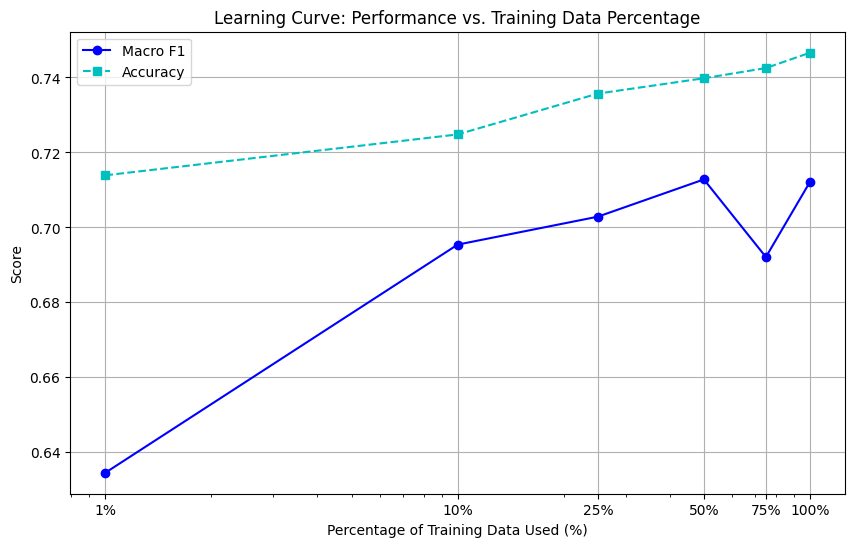

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(df_results_full['percentage'] * 100, df_results_full['macro_f1'],
         marker='o', linestyle='-', color='b', label='Macro F1')
plt.plot(df_results_full['percentage'] * 100, df_results_full['accuracy'],
         marker='s', linestyle='--', color='c', label='Accuracy')
plt.title("Learning Curve: Performance vs. Training Data Percentage")
plt.xlabel("Percentage of Training Data Used (%)")
plt.ylabel("Score")
plt.xscale('log')
plt.xticks(df_results_full['percentage'] * 100, [f"{int(p*100)}%" for p in df_results_full['percentage']])
plt.legend()
plt.grid(True)
plt.show()

This plot show exactly the comments we have made at the end of section a).

### c) Technique Comparison

Here we are comparing to different techniques to see if we can imporve the model. In the guidelines we are asked to try the ones developed in part 2, but since the only ones that achieve the same performance as the baseline model are Data Augmentation and the one using zero-shot with LLMs, those are the only ones we plan to use. Due to the high computational cost of the LLMs use, we decide not to use the LLM technique, also because as seen in part 2 is not improving the model performance. Because of these the only technique we are using from Part 2 is the Data Augmentation, which will be the first one that we are going to try.

Secondly, we decide to try a new techique with the expectation of obtaining better results in the final model. So far we´ve been using the model with the enconder frozen, to avoid overfitting since we were training in a small dataset, but this hardly limited our model training. Therefore, since we have the full dataset to train now, the second technique we are trying here is to unfreeze the enconder. 

**Obs:** In part 2 we tried to unfreeze the enconder and we observed the overfitting. 

#### Trying Data Augmentation

In [5]:
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def replace_with_synonyms(text, num_replacements=2):
    if num_replacements == 0:
        return text

    words = word_tokenize(text)
    if len(words) < 3:
        return text

    valid_words = list(set([w for w in words if w.isalpha()]))
    random.shuffle(valid_words)

    replaced = 0
    for word in valid_words:
        syns = {l.name().replace('_', ' ').lower() for syn in wordnet.synsets(word) for l in syn.lemmas()}
        syns.discard(word.lower())

        if syns:
            words = [random.choice(list(syns)) if w == word else w for w in words]
            replaced += 1

        if replaced >= num_replacements:
            break

    return TreebankWordDetokenizer().detokenize(words)

In [6]:
results_aug = []

for pct in percentages:
    set_seed(11)

    # Manual stratified sampling (same fix as 3a)
    if pct < 1.00:
        parts = []
        for label_val, group in X_train.groupby('label'):
            n = max(1, int(len(group) * pct))
            parts.append(group.sample(n=n, random_state=749))
        df_pct = pd.concat(parts).reset_index(drop=True)
    else:
        df_pct = X_train.reset_index(drop=True)

    df_pct = df_pct.copy()
    df_pct['labels'] = df_pct['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})
    df_pct_clean = df_pct.drop(columns=['label'])

    # Apply synonym augmentation (2 replacements, 2 variations per sentence)
    new_rows = []
    for _, row in df_pct_clean.iterrows():
        for _ in range(2):
            new_text = replace_with_synonyms(row['Sentence'], num_replacements=2)
            if new_text != row['Sentence']:
                new_rows.append({'Sentence': new_text, 'labels': row['labels']})

    df_synthetic_pct = pd.DataFrame(new_rows)
    df_pct_expanded = pd.concat([df_pct_clean, df_synthetic_pct]).drop_duplicates().reset_index(drop=True)

    train_ds_aug = Dataset.from_pandas(df_pct_expanded)
    if '__index_level_0__' in train_ds_aug.column_names:
        train_ds_aug = train_ds_aug.remove_columns(['__index_level_0__'])

    tokenized_train_aug = train_ds_aug.map(tokenize_function, batched=True)

    model_name_aug = "distilbert-base-uncased"
    model_aug_pct = AutoModelForSequenceClassification.from_pretrained(model_name_aug, num_labels=2)
    for param in model_aug_pct.distilbert.parameters():
        param.requires_grad = False

    training_args_aug_pct = TrainingArguments(
        output_dir=f"../results_aug_pct_{int(pct*100)}",
        num_train_epochs=15,
        learning_rate=5e-4,
        per_device_train_batch_size=8,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        seed=7994,
        logging_steps=1,
        report_to="none",
    )

    trainer_aug_pct = Trainer(
        model=model_aug_pct,
        args=training_args_aug_pct,
        train_dataset=tokenized_train_aug,
        eval_dataset=tokenized_eval,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print(f"\nTraining (augmented) with {int(pct*100)}% base data -> {len(df_pct_expanded)} total samples...")
    trainer_aug_pct.train()

    predictions_aug_pct = trainer_aug_pct.predict(tokenized_eval)
    preds_aug_pct = np.argmax(predictions_aug_pct.predictions, axis=-1)
    true_aug_pct = predictions_aug_pct.label_ids

    macro_f1_aug = f1_score(true_aug_pct, preds_aug_pct, average='macro', zero_division=0)
    acc_aug = (preds_aug_pct == true_aug_pct).mean()

    results_aug.append({
        'percentage': pct,
        'n_samples': len(df_pct_expanded),
        'macro_f1': macro_f1_aug,
        'accuracy': acc_aug
    })

    print(f"  -> {int(pct*100)}% base ({len(df_pct_expanded)} total): Macro F1 = {macro_f1_aug:.3f}, Accuracy = {acc_aug:.3f}")

df_results_aug = pd.DataFrame(results_aug)
df_results_aug


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10101.40it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training (augmented) with 1% base data -> 84 total samples...


Epoch,Training Loss,Validation Loss
1,0.562597,0.604359
2,0.329537,0.572723
3,0.359060,0.558612
4,0.289495,0.577617
5,0.082660,0.598988
6,0.030626,0.611761


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.24it/s]


  -> 1% base (84 total): Macro F1 = 0.674, Accuracy = 0.722


...


Training (augmented) with 100% base data -> 8805 total samples...


Epoch,Training Loss,Validation Loss
1,0.500595,0.524311
2,0.556274,0.528510
3,0.559576,0.542394
4,0.739907,0.527217


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.80it/s]


  -> 100% base (8805 total): Macro F1 = 0.717, Accuracy = 0.749


,percentage,n_samples,macro_f1,accuracy
0,0.01,84,0.673943,0.722071
1,0.10,878,0.682463,0.724796
2,0.25,2198,0.705945,0.728883
3,0.50,4403,0.700378,0.735695
4,0.75,6599,0.697486,0.738420
5,1.00,8805,0.717013,0.749319


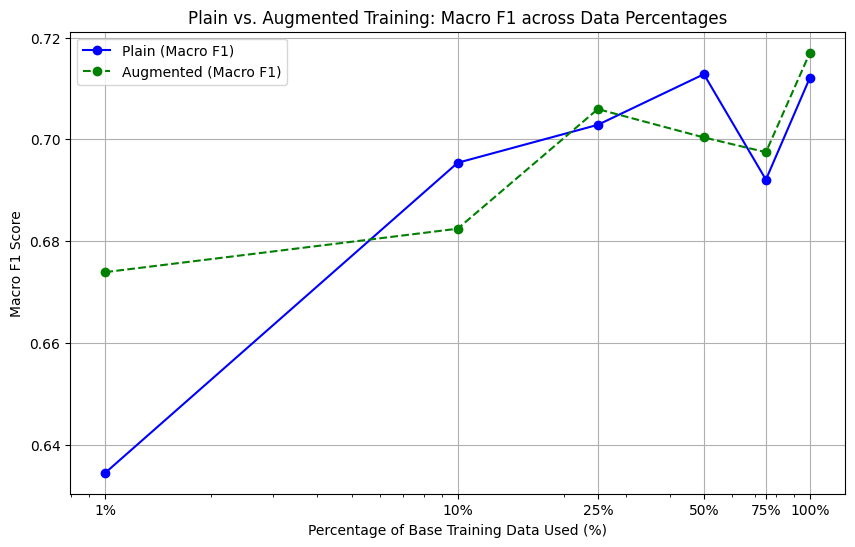

,percentage,n_plain,macro_f1_plain,accuracy_plain,n_augmented,macro_f1_augmented,accuracy_augmented,f1_delta
0,0.01,28,0.634559,0.713896,84,0.673943,0.722071,0.039383
1,0.10,293,0.695406,0.724796,878,0.682463,0.724796,-0.012942
2,0.25,733,0.702859,0.735695,2198,0.705945,0.728883,0.003087
3,0.50,1468,0.712794,0.739782,4403,0.700378,0.735695,-0.012416
4,0.75,2201,0.692094,0.742507,6599,0.697486,0.738420,0.005392
5,1.00,2936,0.712120,0.746594,8805,0.717013,0.749319,0.004893


In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_results_full['percentage'] * 100, df_results_full['macro_f1'],
         marker='o', linestyle='-', color='b', label='Plain (Macro F1)')
plt.plot(df_results_aug['percentage'] * 100, df_results_aug['macro_f1'],
         marker='o', linestyle='--', color='g', label='Augmented (Macro F1)')
plt.title("Plain vs. Augmented Training: Macro F1 across Data Percentages")
plt.xlabel("Percentage of Base Training Data Used (%)")
plt.ylabel("Macro F1 Score")
plt.xscale('log')
plt.xticks(df_results_full['percentage'] * 100, [f"{int(p*100)}%" for p in df_results_full['percentage']])
plt.legend()
plt.grid(True)
plt.show()

df_comparison = pd.DataFrame({
    'percentage': df_results_full['percentage'],
    'n_plain': df_results_full['n_samples'],
    'macro_f1_plain': df_results_full['macro_f1'],
    'accuracy_plain': df_results_full['accuracy'],
    'n_augmented': df_results_aug['n_samples'],
    'macro_f1_augmented': df_results_aug['macro_f1'],
    'accuracy_augmented': df_results_aug['accuracy'],
})
df_comparison['f1_delta'] = df_comparison['macro_f1_augmented'] - df_comparison['macro_f1_plain']
df_comparison

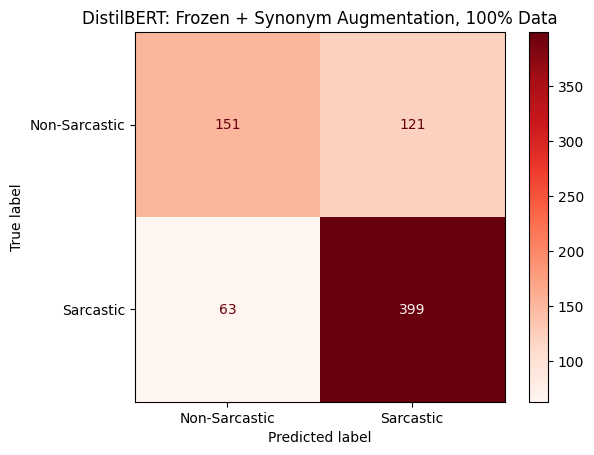

In [ ]:
# Get the predictions from the 100% data run (last iteration)
predictions_aug_100 = trainer_aug_pct.predict(tokenized_eval)
preds_aug_100 = np.argmax(predictions_aug_100.predictions, axis=-1)
true_aug_100 = predictions_aug_100.label_ids

# Confusion matrix
cm_aug = confusion_matrix(true_aug_100, preds_aug_100)
disp_aug = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp_aug.plot(cmap='Reds', values_format='d')
plt.title("DistilBERT: Frozen + Synonym Augmentation, 100% Data")
plt.show()

**Comments:** This time we applied the data augmentation technique from Part 2, again keeping all parameters unchanged. Unlike in Part 2, augmentation produced a meaningful improvement here: as the training data grew from 1% to 100%, macro-F1 increased from 0.674 to 0.717. This contrasts with Part 2, where augmenting an extremely small dataset gave no benefit. We believe this is because augmenting a very small dataset mostly introduces noise rather than useful signal, whereas augmentation becomes effective once there is enough underlying data to build on.

Moreover, notice how, when compared to the performance of data augmentation for our 32-sample dataset, the model is now better at both identifying true positives (it now flags 399, previously it was 391) and true negatives (now 151, previously 136). In other words, the precision and the recall for both the "Sarcastic" and the "Non-Sarcastic" classes has experimented an improvement.


#### Trying to Unfreeze the enconder 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7692.58it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning full DistilBERT (unfrozen) on 100% of training data (2936 samples)...


Epoch,Training Loss,Validation Loss
1,0.706356,0.556026
2,0.675979,0.553809
3,0.655730,0.754248
4,0.102232,0.932644
5,0.002567,1.326482


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.31it/s]



--- Unfrozen DistilBERT (100% data) Results ---
               precision    recall  f1-score   support

Non-Sarcastic       0.62      0.76      0.68       272
    Sarcastic       0.84      0.72      0.78       462

     accuracy                           0.74       734
    macro avg       0.73      0.74      0.73       734
 weighted avg       0.76      0.74      0.74       734

Macro F1 = 0.729, Accuracy = 0.737


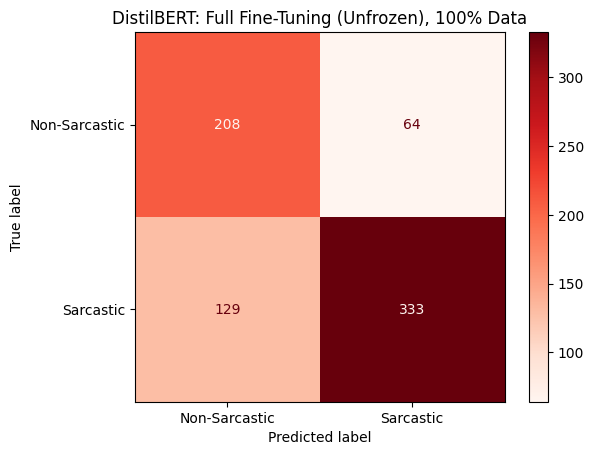

In [9]:
set_seed(11)

# Use the full training set (100%)
df_pct = X_train.reset_index(drop=True).copy()
df_pct['labels'] = df_pct['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})
df_pct_clean = df_pct.drop(columns=['label'])

train_ds = Dataset.from_pandas(df_pct_clean)
if '__index_level_0__' in train_ds.column_names:
    train_ds = train_ds.remove_columns(['__index_level_0__'])

tokenized_train_full = train_ds.map(tokenize_function, batched=True)

# Fresh DistilBERT, UNFROZEN backbone (full fine-tuning)
model_name = "distilbert-base-uncased"
model_unfrozen = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# Note: no freezing loop here — all parameters remain trainable

training_args_unfrozen = TrainingArguments(
    output_dir="../results_unfrozen_100",
    num_train_epochs=15,
    learning_rate=2e-5,  # much smaller LR for full fine-tuning
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    seed=7994,
    logging_steps=1,
    report_to="none",
)

trainer_unfrozen = Trainer(
    model=model_unfrozen,
    args=training_args_unfrozen,
    train_dataset=tokenized_train_full,
    eval_dataset=tokenized_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print(f"Fine-tuning full DistilBERT (unfrozen) on 100% of training data ({len(df_pct_clean)} samples)...")
trainer_unfrozen.train()

predictions_unfrozen = trainer_unfrozen.predict(tokenized_eval)
preds_unfrozen = np.argmax(predictions_unfrozen.predictions, axis=-1)
true_unfrozen = predictions_unfrozen.label_ids

macro_f1_unfrozen = f1_score(true_unfrozen, preds_unfrozen, average='macro', zero_division=0)
acc_unfrozen = (preds_unfrozen == true_unfrozen).mean()

print(f"\n--- Unfrozen DistilBERT (100% data) Results ---")
print(classification_report(true_unfrozen, preds_unfrozen, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))
print(f"Macro F1 = {macro_f1_unfrozen:.3f}, Accuracy = {acc_unfrozen:.3f}")

# Confusion matrix
cm_unfrozen = confusion_matrix(true_unfrozen, preds_unfrozen)
disp_unfrozen = ConfusionMatrixDisplay(confusion_matrix=cm_unfrozen, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp_unfrozen.plot(cmap='Reds', values_format='d')
plt.title("DistilBERT: Full Fine-Tuning (Unfrozen), 100% Data")
plt.show()

**Comments:** We tested our earlier hypothesis that unfreezing the encoder could further improve performance. In Part 2, we had tried this but observed clear overfitting, so we left the encoder frozen. With the larger dataset available here, we revisited the idea by fine-tuning the encoder on 100% of the training set. We used the base DistilBERT model with all parameters unchanged except the learning rate, which we raised to 2e-5 to reduce the risk of rapid overfitting. This model slightly improved our main metrics: macro-F1 rose from 0.724 (our best augmented model) to 0.73, with accuracy reaching 0.74. Furthermore, we can observe how the confusion matrix for this model is the opposite to that of the previous model. If the previous model excelled in terms of true positive rate while struggling with false positives, in the model we just presented the dynamic is shifted. Now we have built a model that struggles with false negatives, while being more prolific in terms of the true negative rate. 

Looking at the confusion matrix and the per class scores, the model performs clearly better on the Sarcastic class than on the Non-Sarcastic class. The Sarcastic class reaches a precision of 0.84, a recall of 0.72 and an F1 of 0.78, while the Non-Sarcastic class only reaches a precision of 0.62, a recall of 0.76 and an F1 of 0.68. The gap is driven mainly by precision rather than recall, since recall is fairly balanced across both classes (0.72 versus 0.72), meaning the model is not simply ignoring the minority class. The low Non-Sarcastic precision comes from the largest off diagonal cell in the matrix: 129 truly sarcastic sentences are predicted as non-sarcastic, compared to only 64 errors in the opposite direction. In other words, the model's dominant mistake is missing sarcasm and reading sarcastic sentences literally, which with the inherent difficulty of detecting sarcasm.


### d) Methodology Analysis

**Comments:** The learning curve (3a and 3b) shows the model improved substantially when moving from 1% to 25% of the data (macro F1: 0.635 to 0.703), but gains flattened out from 50% onward (macro F1 oscillating between 0.692 and 0.713).

Applying the synonym based augmentation from Part 2b to the full training set (Part 3c) gave a modest improvement, raising macro F1 from 0.712 to 0.717 and accuracy from 0.747 to 0.749, which confirms that augmentation remains useful even with much more data available.

To address the plateau itself, our hypothesis was that it stemmed from freezing the encoder, a choice made to keep results comparable with Part 2's setup. With the encoder frozen, the model's weights are never updated to account for the new data; only the classification head adapts, so additional examples beyond a certain point provide little new signal for it to exploit. To test this, we ran full fine-tuning on the full dataset with the encoder unfrozen. This improved macro F1 to 0.73 and accuracy to 0.74, our best result overall, which supports our hypothesis: once the encoder itself can be reweighted to the task, the model extracts meaningfully more from the same data.

Looking across the confusion matrices, the structure of the errors stays consistent throughout these stages even as the overall scores rise. In every case the Sarcastic class is predicted more reliably than the Non-Sarcastic class, and the dominant mistake is always sarcasm being read literally, that is, truly sarcastic sentences predicted as non-sarcastic. In our best model this is clearly visible: the Sarcastic class reaches a precision of 0.84 and a recall of 0.72 (F1 of 0.78), while the Non-Sarcastic class only reaches a precision of 0.62 and a recall of 0.76 (F1 of 0.68). The largest off diagonal cell holds 129 sarcastic sentences classified as non-sarcastic, against only 64 errors in the opposite direction. What unfreezing the encoder mainly buys us is a reduction in these missed sarcasm cases rather than a change in the overall error pattern, which is consistent both with the class imbalance in the data and with the inherent difficulty of recognizing sarcasm.

SOA and human comparison: The final 0.73 narrows but does not close the gap to fine-tuned RoBERTa benchmarks (F1 ≈ 0.80, Part 1a), leaving a difference of roughly 0.07 macro F1. It does, however, exceed our own inter-annotator agreement (63.92%) and is competitive with the "no-context" human sarcasm judgment reported in the literature (F1 ≈ 0.62). This is an important point of interpretation: when humans judge sarcasm from a single sentence without surrounding conversation, their performance is close to what our model achieves, so our model effectively matches human ability under the same informational constraints. The remaining gap to the state of the art is probably best explained by encoder capacity, since RoBERTa is a substantially larger model, rather than by our training strategy. 